In [3]:
#@title 📦 Kaggle Competition Loader { display-mode: "form" }
#@markdown ---
#@markdown ### How to use
#@markdown 1. In Colab, add **two** secrets via the 🔑 Secrets panel (left sidebar):
#@markdown    - `KAGGLE_USERNAME` → your Kaggle username
#@markdown    - `KAGGLE_KEY` → your Kaggle API key
#@markdown    Toggle "Notebook access" on for both.
#@markdown 2. Run this cell (code stays hidden — double-click the title to peek).
#@markdown 3. When prompted, paste the **full Kaggle competition URL**
#@markdown    (e.g. `https://www.kaggle.com/c/titanic`) — or just the slug.
#@markdown 4. After it finishes, your data is available as:
#@markdown    - `data['train.csv']`, `data['test.csv']`, etc. → pandas DataFrames
#@markdown    - `data['some_file.ext']` → file path (non-CSV files)
#@markdown    - `data_dir` → the local folder containing everything
#@markdown ---

import os
import re
import shutil
import kagglehub
import pandas as pd


def _authenticate_kaggle():
    try:
        from google.colab import userdata
    except ImportError:
        return

    def _get(name):
        try:
            return userdata.get(name)
        except Exception:
            return None

    username = _get("KAGGLE_USERNAME")
    key = _get("KAGGLE_KEY") or _get("KAGGLE_LEGACY_KEY")
    token = _get("KAGGLE_API_TOKEN")

    # New-style token (KGAT_...) — may have been saved under KAGGLE_KEY
    if key and key.startswith("KGAT_"):
        token, key = key, None

    if token:
        os.environ["KAGGLE_API_TOKEN"] = token
        os.environ.pop("KAGGLE_KEY", None)       # avoid conflicting creds
        os.environ.pop("KAGGLE_USERNAME", None)
        return

    if username and key:
        os.environ["KAGGLE_USERNAME"] = username
        os.environ["KAGGLE_KEY"] = key
        return

    raise RuntimeError(
        "No usable Kaggle credentials found. Add either KAGGLE_API_TOKEN "
        "(new KGAT_ token) or KAGGLE_USERNAME + KAGGLE_KEY (legacy) "
        "in the Colab 🔑 Secrets panel with Notebook access on."
    )


def _parse_kaggle_ref(text: str):
    """
    Determines whether the input points to a Kaggle *dataset* or
    *competition*, and extracts the identifier kagglehub needs.

    Returns:
        (kind, ref) where kind is 'dataset' or 'competition', and ref is
        either "owner/dataset-slug" (datasets) or "comp-slug" (competitions).
    """
    text = text.strip().rstrip('/')

    # Full dataset URL: kaggle.com/datasets/<owner>/<slug>
    match = re.search(r'kaggle\.com/datasets/([^/?#]+)/([^/?#]+)', text)
    if match:
        return 'dataset', f"{match.group(1)}/{match.group(2)}"

    # Full competition URL: kaggle.com/c/<slug> or kaggle.com/competitions/<slug>
    match = re.search(r'kaggle\.com/(?:c|competitions)/([^/?#]+)', text)
    if match:
        return 'competition', match.group(1)

    # Any other kaggle.com URL shape — can't reliably classify it
    if "kaggle.com" in text:
        return None, text.split('/')[-1]

    # Bare input, no domain: "owner/slug" implies a dataset handle;
    # a single token is treated as a competition slug.
    if '/' in text:
        return 'dataset', text
    return 'competition', text


def fetch_kaggle_competition(comp_url: str = None, copy_to_local: bool = True):
    """
    Downloads a Kaggle dataset or competition via kagglehub and loads all CSVs.

    Args:
        comp_url: Full Kaggle dataset/competition URL, or a slug
            ("comp-slug" for a competition, "owner/dataset-slug" for a
            dataset). If None, you'll be prompted.
        copy_to_local: If True, copies files out of the kagglehub cache into
            a local folder named after the slug.

    Returns:
        data: dict mapping filename -> DataFrame (for .csv) or filepath (other files)
        working_path: directory containing the dataset files
    """
    comp_input = comp_url or input("Paste Kaggle dataset/competition URL (or slug): ").strip()
    kind, comp_id = _parse_kaggle_ref(comp_input)

    if not comp_id:
        raise ValueError("Could not parse a dataset/competition identifier from that input.")
    if kind is None:
        raise ValueError(
            f"Couldn't tell whether '{comp_input}' is a dataset or a competition. "
            "Paste the full URL (kaggle.com/datasets/... or kaggle.com/c/...) "
            "or a bare slug (owner/dataset-slug, or comp-slug)."
        )

    print(f"\n[1/3] Authenticating & downloading {kind}: '{comp_id}'...")
    _authenticate_kaggle()
    try:
        if kind == 'dataset':
            cache_path = kagglehub.dataset_download(comp_id)
        else:
            cache_path = kagglehub.competition_download(comp_id)
    except Exception as e:
        if kind == 'competition':
            raise RuntimeError(
                f"Failed to download competition '{comp_id}'. If this is a 403, "
                f"make sure you've accepted the competition rules at "
                f"https://kaggle.com/competitions/{comp_id}/rules"
            ) from e
        raise RuntimeError(
            f"Failed to download dataset '{comp_id}'. Double-check the "
            "owner/slug is correct and the dataset is public (or you have access)."
        ) from e

    local_name = comp_id.replace('/', '_')
    target_dir = os.path.join(os.getcwd(), local_name)
    if copy_to_local:
        if os.path.exists(target_dir):
            shutil.rmtree(target_dir)
        shutil.copytree(cache_path, target_dir)
        working_path = target_dir
    else:
        working_path = cache_path

    print(f"[2/3] Files localized to: {working_path}")

    data = {}
    print("\n[3/3] Inspecting dataset contents:")
    for root, _, filenames in os.walk(working_path):
        for fname in sorted(filenames):
            fpath = os.path.join(root, fname)
            if fname.endswith('.csv'):
                data[fname] = pd.read_csv(fpath)
                print(f"  • {fname:30s} shape={data[fname].shape} -> data['{fname}']")
            else:
                data[fname] = fpath
                print(f"  • {fname:30s} (path saved) -> data['{fname}']")

    return data, working_path


# ==========================================
# RUN — paste your competition URL when asked
# ==========================================
data, data_dir = fetch_kaggle_competition()
print("\nAvailable keys:", list(data.keys()))

Paste Kaggle dataset/competition URL (or slug): https://www.kaggle.com/competitions/titanic

[1/3] Authenticating & downloading competition: 'titanic'...


100%|██████████| 34.1k/34.1k [00:00<00:00, 26.1MB/s]

Extracting files...
[2/3] Files localized to: /content/titanic

[3/3] Inspecting dataset contents:
  • gender_submission.csv          shape=(418, 2) -> data['gender_submission.csv']
  • test.csv                       shape=(418, 11) -> data['test.csv']
  • train.csv                      shape=(891, 12) -> data['train.csv']

Available keys: ['gender_submission.csv', 'test.csv', 'train.csv']


# ML Labs 1-6: Code Sheet on the Titanic Dataset
**Dataset:** Kaggle *Titanic: Machine Learning from Disaster* - https://www.kaggle.com/competitions/titanic
Files: `train.csv` (891 rows, has `Survived`) and `test.csv` (418 rows, no label).

**Setup (pick one):**
- **Kaggle notebook:** the files are at `/kaggle/input/titanic/`
- **Colab / local:** download `train.csv` + `test.csv` from the competition page and put them next to this notebook
- **No files at all:** the loader falls back to seaborn's copy of Titanic (train only, same column names)

Target: `Survived` (0/1). Classification labs use it directly. The regression lab (Lab 5) predicts `Fare`.

## Setup + Load Data

In [4]:
!pip -q install xgboost lightgbm

In [5]:
import os, math, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from collections import Counter, defaultdict

def load_titanic():
    for d in ["", "/kaggle/input/titanic/", "/content/titanic/", "data/"]:
        if os.path.exists(d + "train.csv"):
            tr = pd.read_csv(d + "train.csv")
            te = pd.read_csv(d + "test.csv") if os.path.exists(d + "test.csv") else None
            print("Loaded Kaggle files from:", d or "./")
            return tr, te
    print("Kaggle files not found -> using seaborn copy (no test set)")
    s = sns.load_dataset("titanic").rename(columns={
        "survived": "Survived", "pclass": "Pclass", "sex": "Sex", "age": "Age",
        "sibsp": "SibSp", "parch": "Parch", "fare": "Fare", "embarked": "Embarked"})
    s["PassengerId"] = range(1, len(s) + 1)
    return s[["PassengerId", "Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]], None

train, test = load_titanic()
print(train.shape, None if test is None else test.shape)
train.head()

Loaded Kaggle files from: /content/titanic/
(891, 12) (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


**Inspect data**

In [7]:
train.head()                        # first 5 rows
train.tail(2)                       # last 2 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [8]:
print(train.info())                        # dtypes + non-null counts
print(train.describe())                    # stats of numeric cols

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.48659

In [9]:
train.sample(2, random_state=42)    # random rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S


In [10]:
print(train["Survived"].value_counts())   # target balance
print("---")
print(train["Pclass"].unique())     # distinct values
print("---")
print(train.shape, train.size)      # (rows, cols), total cells
print("---")
print(train.isnull().sum())         # missing per column
print("---")
print(train.duplicated().sum())     # duplicate rows

Survived
0    549
1    342
Name: count, dtype: int64
---
[3 1 2]
---
(891, 12) 10692
---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
---
0


**Select and filter**

In [11]:
train["Age"].head(2)                        # one column (Series)

,Age
0,22.0
1,38.0


In [12]:
train[["Age", "Fare"]].head(2)              # multiple columns

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833


In [13]:
train.iloc[0:2, 0:3]                # by integer position

,PassengerId,Survived,Pclass
0,1,0,3
1,2,1,1


In [14]:
train.loc[0:2, ["Sex", "Age"]]      # by label

,Sex,Age
0,male,22.0
1,female,38.0
2,female,26.0


In [15]:
train[train["Age"] >= 60].head(3)                              # single condition

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,B30,C
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C


In [16]:
train[(train["Age"] >= 20) & (train["Age"] <= 30)]     # AND

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
12,13,0,3,"Saundercock, Mr. William Henry",male,20.0,0,0,A/5. 2151,8.0500,NaN,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S
...,...,...,...,...,...,...,...,...,...,...,...,...
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S


In [17]:
train[(train["Pclass"] == 1) | (train["Fare"] > 100)]  # OR

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [18]:
train[~(train["Sex"] == "male")]                       # NOT

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...,...
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [19]:
train[(train["Age"] >= 20) ^ (train["Age"] >= 40)]     # XOR (exactly one true)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


**Modify and handle missing values**

In [20]:
d = train.copy() # `d = train` just changes the name of the dataFrame

d["IsChild"] = d["Age"] < 12                    # new boolean column
d["FamilySize"] = d["SibSp"] + d["Parch"] + 1   # derived column
d["Fare"] = d["Fare"] + 0                       # modify column (example)
d = d.drop(columns=["IsChild"])                 # drop column
d = d.sort_values("Fare", ascending=False)      # sort
d["AgeGroup"] = d["Age"].apply(lambda x: "Child" if x < 18 else "Adult")  # apply
d["Age"] = d["Age"].fillna(d["Age"].median())   # fill NaN with median
d.dropna(subset=["Embarked"]).shape             # drop rows with NaN in a column

(889, 14)

**Aggregation, groupby, pivot, joins**

In [21]:
print("---")
print(train["Fare"].sum(), train["Fare"].mean(), train["Fare"].median())
print("---")
print(train["Fare"].min(), train["Fare"].max(), train["Fare"].std())
print("---")
print(train["Age"].count(), train["Embarked"].nunique())

print("---")
print(train.groupby("Sex")["Survived"].mean())          # survival rate per sex
print("---")
print(train.groupby("Pclass").agg(
    Total=("Fare", "sum"), Avg=("Fare", "mean"), Max=("Fare", "max")))
print("---")
print(train.groupby(["Pclass", "Sex"])["Survived"].mean())  # multi-column group

print("---")
print(train.pivot_table(values="Survived", index="Pclass",
                        columns="Sex", aggfunc="mean", fill_value=0))

# joins on a key (PassengerId) with a small helper table
extra = pd.DataFrame({"PassengerId": [1, 2, 9999], "VIP": [False, True, True]})
print("---")
print(pd.merge(train[["PassengerId", "Sex"]].head(3), extra, on="PassengerId", how="inner"))
print("---")
print(pd.merge(train[["PassengerId", "Sex"]].head(3), extra, on="PassengerId", how="left"))
print("---")
print(train[["PassengerId", "Sex"]].head(3).set_index("PassengerId")
      .join(extra.set_index("PassengerId"), how="left"))

---
28693.9493 32.204207968574636 14.4542
---
0.0 512.3292 49.693428597180905
---
714 3
---
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
---
             Total        Avg       Max
Pclass                                 
1       18177.4125  84.154687  512.3292
2        3801.8417  20.662183   73.5000
3        6714.6951  13.675550   69.5500
---
Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64
---
Sex       female      male
Pclass                    
1       0.968085  0.368852
2       0.921053  0.157407
3       0.500000  0.135447
---
   PassengerId     Sex    VIP
0            1    male  False
1            2  female   True
---
   PassengerId     Sex    VIP
0            1    male  False
1            2  female   True
2            3  female    NaN
---
                Sex    VIP
PassengerId               
1   

In [22]:
# pd.DataFrame.groupby?        # full docstring in a pane (IPython)
help(pd.DataFrame.agg)       # full docstring printed in the cell output

Help on function aggregate in module pandas.core.frame:

aggregate(self, func=None, axis: 'Axis' = 0, *args, **kwargs)
    Aggregate using one or more operations over the specified axis.

    Parameters
    ----------
    func : function, str, list or dict
        Function to use for aggregating the data. If a function, must either
        work when passed a DataFrame or when passed to DataFrame.apply.

        Accepted combinations are:

        - function
        - string function name
        - list of functions and/or function names, e.g. ``[np.sum, 'mean']``
        - dict of axis labels -> functions, function names or list of such.
    axis : {0 or 'index', 1 or 'columns'}, default 0
            If 0 or 'index': apply function to each column.
            If 1 or 'columns': apply function to each row.
    *args
        Positional arguments to pass to `func`.
    **kwargs
        Keyword arguments to pass to `func`.

    Returns
    -------
    scalar, Series or DataFrame

        

In [23]:
# pivot_table: lists give multi-level rows or columns
train.pivot_table(values="Survived", index=["Pclass", "Embarked"],
                  columns="Sex", aggfunc="mean")

Sex                female      male
Pclass Embarked                    
1      C         0.976744  0.404762
       Q         1.000000  0.000000
       S         0.958333  0.354430
2      C         1.000000  0.200000
       Q         1.000000  0.000000
       S         0.910448  0.154639
3      C         0.652174  0.232558
       Q         0.727273  0.076923
       S         0.375000  0.128302

In [24]:
# or aggregate more than one value column
train.pivot_table(values=["Survived", "Fare"], index="Pclass",
                  columns="Sex", aggfunc="mean")

Fare             Survived          
Sex         female       male    female      male
Pclass                                           
1       106.125798  67.226127  0.968085  0.368852
2        21.970121  19.741782  0.921053  0.157407
3        16.118810  12.661633  0.500000  0.135447

In [25]:
# unstack: group by 3 columns, then choose which index level to spread out
g = train.groupby(["Pclass", "Embarked", "Sex"])["Survived"].mean()
g.unstack()               # spreads the last level (Sex)

Sex                female      male
Pclass Embarked                    
1      C         0.976744  0.404762
       Q         1.000000  0.000000
       S         0.958333  0.354430
2      C         1.000000  0.200000
       Q         1.000000  0.000000
       S         0.910448  0.154639
3      C         0.652174  0.232558
       Q         0.727273  0.076923
       S         0.375000  0.128302

In [26]:
g.unstack("Embarked")     # spreads a level by name

Embarked              C         Q         S
Pclass Sex                                 
1      female  0.976744  1.000000  0.958333
       male    0.404762  0.000000  0.354430
2      female  1.000000  1.000000  0.910448
       male    0.200000  0.000000  0.154639
3      female  0.652174  0.727273  0.375000
       male    0.232558  0.076923  0.128302

In [27]:
# g = train.groupby(["Pclass", "Embarked", "Sex"])["Survived"].mean()
g.unstack(level=1)

Embarked              C         Q         S
Pclass Sex                                 
1      female  0.976744  1.000000  0.958333
       male    0.404762  0.000000  0.354430
2      female  1.000000  1.000000  0.910448
       male    0.200000  0.000000  0.154639
3      female  0.652174  0.727273  0.375000
       male    0.232558  0.076923  0.128302

In [28]:
g.unstack("Sex")     # spreads a level by name

Sex                female      male
Pclass Embarked                    
1      C         0.976744  0.404762
       Q         1.000000  0.000000
       S         0.958333  0.354430
2      C         1.000000  0.200000
       Q         1.000000  0.000000
       S         0.910448  0.154639
3      C         0.652174  0.232558
       Q         0.727273  0.076923
       S         0.375000  0.128302

**Plots**

               Age      Fare  Survived
Age       1.000000  0.973207  0.495130
Fare      0.973207  1.000000  0.500868
Survived  0.495130  0.500868  1.000000


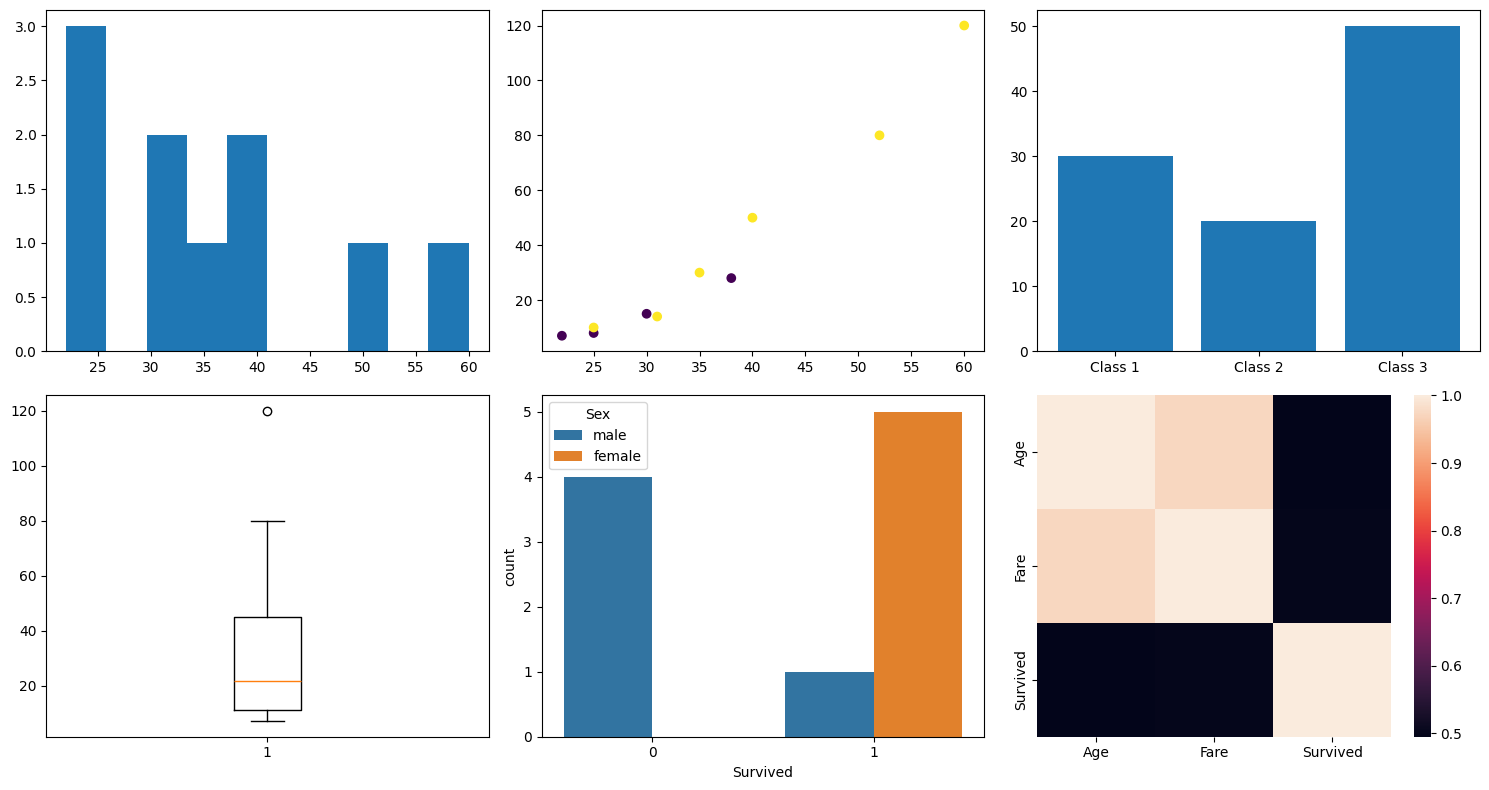

In [29]:
# fig, ax = plt.subplots(2, 3, figsize=(15, 8))
# ax[0,0].hist(train["Age"].dropna(), bins=20); ax[0,0].set_title("Histogram: Age")
# ax[0,1].scatter(train["Age"], train["Fare"], c=train["Survived"], cmap="coolwarm"); ax[0,1].set_title("Scatter: Age vs Fare")

# train["Pclass"].value_counts().sort_index().plot(kind="bar", ax=ax[0,2], title="Bar: Pclass counts")
# ax[1,0].boxplot(train["Fare"]); ax[1,0].set_title("Box: Fare (outliers)")
# sns.countplot(x="Survived", hue="Sex", data=train, ax=ax[1,1])
# ax[1,1].set_title("Survived by Sex")
# sns.heatmap(train.select_dtypes("number").corr(), annot=True, fmt=".2f", ax=ax[1,2])
# ax[1,2].set_title("Correlation")
# plt.tight_layout(); plt.show()

# import plotly.express as px
# px.bar(train.groupby("Pclass")["Survived"].mean().reset_index(),
#        x="Pclass", y="Survived", title="Interactive: survival rate by class")


import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

df = pd.DataFrame({
    "Age":      [22, 25, 25, 30, 31, 35, 38, 40, 52, 60],
    "Fare":     [7, 8, 10, 15, 14, 30, 28, 50, 80, 120],
    "Survived": [0, 0, 1, 0, 1, 1, 0, 1, 1, 1],
    "Sex":      ["male", "male", "female", "male", "female",
                 "female", "male", "female", "female", "male"],
})

corr = df.corr(numeric_only=True)

print(corr)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ax[0,0].hist(df["Age"])
ax[0,1].scatter(df["Age"], df["Fare"], c=df["Survived"])
ax[0,2].bar(["Class 1", "Class 2", "Class 3"], [30, 20, 50])
ax[1,0].boxplot(df["Fare"])
sns.countplot(x="Survived", hue="Sex", data=df, ax=ax[1,1])
sns.heatmap(df.corr(numeric_only=True), ax=ax[1,2])
plt.tight_layout()


<Axes: >

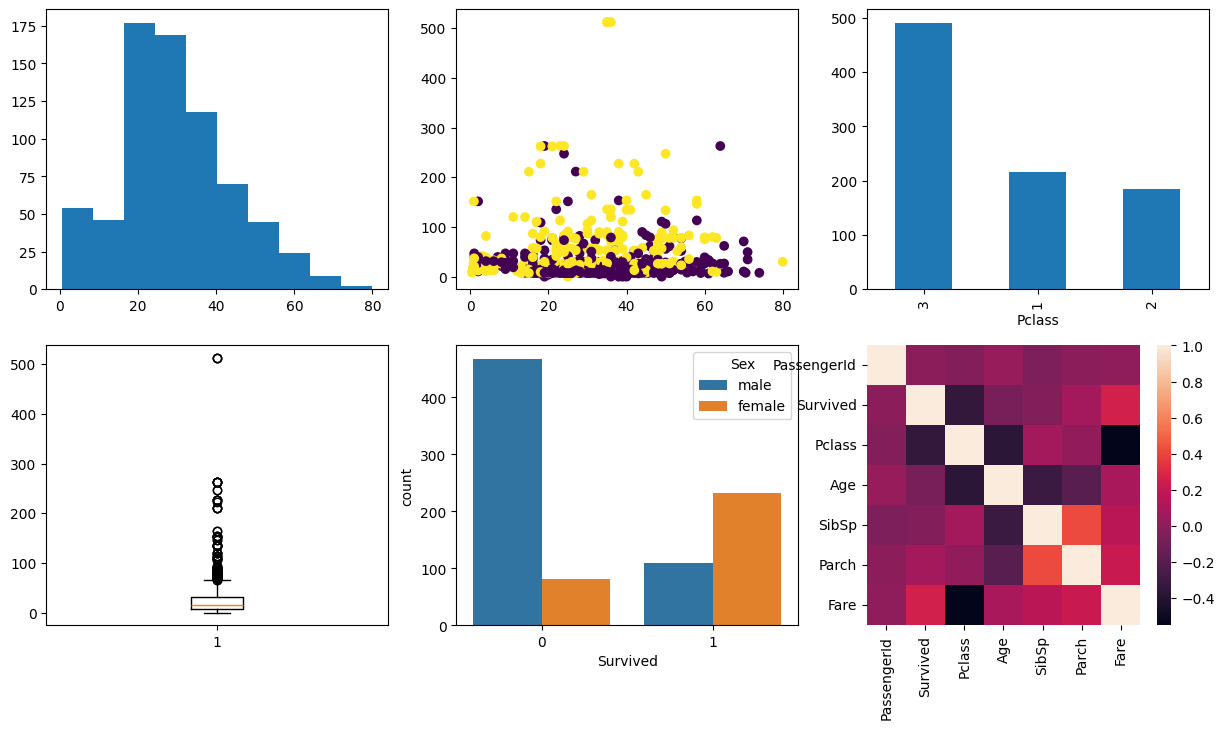

In [30]:
fig, ax = plt.subplots(2, 3, figsize = (15,8))
ax[0,0].hist(train["Age"].dropna())              # dropna: hist fails on NaN
ax[0,1].scatter(train["Age"], train["Fare"], c=train["Survived"])
train["Pclass"].value_counts().plot(kind="bar", ax=ax[0,2])
ax[1,0].boxplot(train["Fare"])
sns.countplot(x="Survived", hue="Sex", data=train, ax=ax[1,1])
sns.heatmap(train.select_dtypes("number").corr(), ax=ax[1,2])

              Hours     Marks  Absences  Shoe_size
Hours      1.000000  0.999405 -0.995418  -0.271448
Marks      0.999405  1.000000 -0.994826  -0.271287
Absences  -0.995418 -0.994826  1.000000   0.185435
Shoe_size -0.271448 -0.271287  0.185435   1.000000


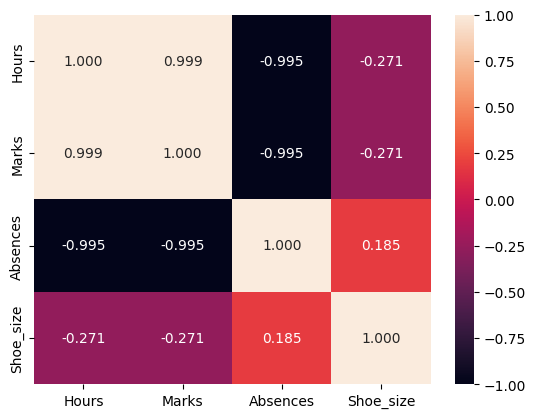

In [31]:
df = pd.DataFrame({
    "Hours":      [1, 2, 3, 4, 5, 6],
    "Marks":      [40, 48, 55, 63, 72, 80],   # rises with Hours
    "Absences":   [8, 7, 5, 4, 2, 1],         # falls as Hours rises
    "Shoe_size":  [9, 6, 8, 7, 9, 6],         # unrelated
})
print(df.corr())
sns.heatmap(df.corr(), annot=True, fmt=".3f", vmin=-1, vmax=1)
plt.show()

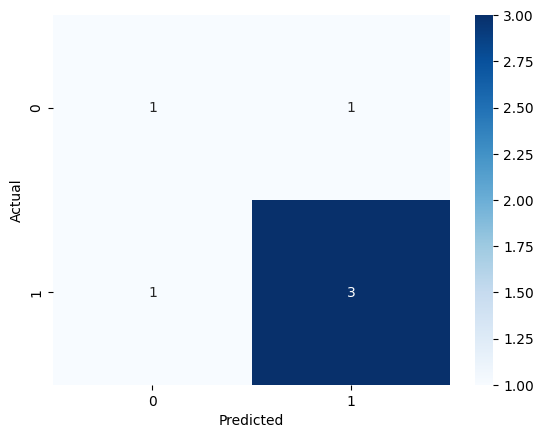

In [32]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

df = pd.DataFrame({
    "Hours": [1, 2, 3, 4, 5, 6],
    "Marks": [40, 48, 55, 63, 72, 80],
})

y_true = (df["Marks"] >= 50).astype(int)   # actual: [0, 0, 1, 1, 1, 1]
y_pred = [0, 1, 1, 1, 0, 1]                # pretend model output (2 mistakes)

cm = confusion_matrix(y_true, y_pred)      # [[TN, FP], [FN, TP]] = [[1, 1], [1, 3]]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

## Shared preprocessing (used by all later labs)
Fills missing values with **train** statistics, encodes categoricals, adds `FamilySize`.

In [33]:
age_med  = train["Age"].median()
fare_med = train["Fare"].median()
emb_mode = train["Embarked"].mode()[0]

def prep(d):
    d = d.copy()
    d["Age"] = d["Age"].fillna(age_med)
    d["Fare"] = d["Fare"].fillna(fare_med)
    d["Embarked"] = d["Embarked"].fillna(emb_mode).map({"S": 0, "C": 1, "Q": 2})
    d["Sex"] = d["Sex"].map({"male": 0, "female": 1})
    d["FamilySize"] = d["SibSp"] + d["Parch"] + 1
    return d

features = ["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch", "FamilySize", "Embarked"]
tr = prep(train)
X, y = tr[features], tr["Survived"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)       # stratify keeps class ratio
print(X_train.shape, X_test.shape)

(712, 8) (179, 8)


# LAB 2: OOP Classifiers (Majority Vote, Memorizer, Stump)

**0-1 error:** fraction of wrong predictions.

In [34]:
def classification_error(y_true, y_pred):
    mistakes = 0
    for actual, predicted in zip(y_true, y_pred):
        if actual != predicted:
            mistakes += 1
    return mistakes / len(y_true)

**Base class:** shared `score()` so subclasses only implement `fit` and `predict`.

In [35]:
class BaseClassifier:
    def fit(self, X, y):
        raise NotImplementedError

    def predict(self, X):
        raise NotImplementedError

    def score(self, X, y):
        predictions = self.predict(X)
        correct = sum(a == p for a, p in zip(y, predictions))
        return correct / len(y)

**Majority Vote:** ignores features, always predicts the most common training label (baseline).

In [36]:
class MajorityVoteClassifier(BaseClassifier):
    def __init__(self):
        self.majority_label = None

    def fit(self, X, y):
        self.majority_label = Counter(y).most_common(1)[0][0]
        return self

    def predict(self, X):
        return [self.majority_label for _ in X]

**Memorizer:** stores every training row; random label for unseen rows. Train error 0, poor generalization.

In [37]:
class MemorizerClassifier(BaseClassifier):
    def __init__(self):
        self.memory = {}
        self.labels = []

    def fit(self, X, y):
        self.labels = list(set(y))
        for features_, label in zip(X, y):
            self.memory[tuple(features_)] = label
        return self

    def predict(self, X):
        preds = []
        for features_ in X:
            key = tuple(features_)
            preds.append(self.memory[key] if key in self.memory
                         else random.choice(self.labels))
        return preds

**Decision Stump:** one-feature rule, majority label per feature value.

In [38]:
class DecisionStumpClassifier(BaseClassifier):
    def __init__(self, feature_index=0):
        self.feature_index = feature_index
        self.rules = {}
        self.default_label = None

    def fit(self, X, y):
        groups = defaultdict(list)
        for features_, label in zip(X, y):
            groups[features_[self.feature_index]].append(label)
        self.rules = {v: Counter(l).most_common(1)[0][0] for v, l in groups.items()}
        self.default_label = Counter(y).most_common(1)[0][0]   # for unseen values
        return self

    def predict(self, X):
        return [self.rules.get(f[self.feature_index], self.default_label) for f in X]

**Compare on Titanic** (features: Pclass, Sex, Age, Fare). Stump is tried on each feature.

In [39]:
f2 = ["Pclass", "Sex", "Age", "Fare"]
Xtr2, Xte2 = X_train[f2].values.tolist(), X_test[f2].values.tolist()
ytr2, yte2 = y_train.tolist(), y_test.tolist()

models = {"Majority Vote": MajorityVoteClassifier().fit(Xtr2, ytr2),
          "Memorizer": MemorizerClassifier().fit(Xtr2, ytr2)}
for i, name in enumerate(f2):
    models[f"Stump({name})"] = DecisionStumpClassifier(feature_index=i).fit(Xtr2, ytr2)

for name, m in models.items():
    print(f"{name:18s} train err {classification_error(ytr2, m.predict(Xtr2)):.3f} | "
          f"test err {classification_error(yte2, m.predict(Xte2)):.3f}")

Majority Vote      train err 0.383 | test err 0.385
Memorizer          train err 0.024 | test err 0.385
Stump(Pclass)      train err 0.312 | test err 0.358
Stump(Sex)         train err 0.211 | test err 0.223
Stump(Age)         train err 0.317 | test err 0.430
Stump(Fare)        train err 0.174 | test err 0.346


Expect: Memorizer train error ~0 but weak test error; the `Sex` stump beats Majority Vote (best single feature).

# LAB 3: Decision Tree from Scratch (Entropy, MI, Recursive Training)

**Entropy:** impurity of a label list (0 = pure, 1 = 50/50 binary).

In [40]:
def entropy(labels):
    if len(labels) == 0:
        return 0
    counts = {}
    for label in labels:
        counts[label] = counts.get(label, 0) + 1
    total = len(labels)
    result = 0
    for count in counts.values():
        p = count / total
        result -= p * math.log2(p)
    return result

**Conditional entropy + Mutual Information:** highest MI = best split feature.

In [41]:
def conditional_entropy(dataset, feature, label_col="Label"):
    total = len(dataset)
    weighted = 0
    for value in set(row[feature] for row in dataset):
        subset = [row[label_col] for row in dataset if row[feature] == value]
        weighted += (len(subset) / total) * entropy(subset)
    return weighted

def mutual_information(dataset, feature, label_col="Label"):
    labels = [row[label_col] for row in dataset]
    return entropy(labels) - conditional_entropy(dataset, feature, label_col)

**Node, predict, recursive train**

In [42]:
class Node:
    def __init__(self, node_type, label=None, feature=None):
        self.type = node_type      # "leaf" or "internal"
        self.label = label         # leaf only
        self.feature = feature     # internal only
        self.branches = {}         # feature value -> child Node

def predict(tree, x):
    current = tree
    while current.type != "leaf":
        current = current.branches[x[current.feature]]
    return current.label

def majority_label(dataset, label_col="Label"):
    return Counter(row[label_col] for row in dataset).most_common(1)[0][0]

def train_tree(dataset, features, label_col="Label"):
    labels = [row[label_col] for row in dataset]
    if len(set(labels)) == 1:                         # base: all same label
        return Node("leaf", label=labels[0])
    if len(features) == 0:                            # base: no features left
        return Node("leaf", label=majority_label(dataset, label_col))
    best = max(features, key=lambda f: mutual_information(dataset, f, label_col))
    node = Node("internal", feature=best)
    remaining = [f for f in features if f != best]
    for value in set(row[best] for row in dataset):
        subset = [row for row in dataset if row[best] == value]
        node.branches[value] = train_tree(subset, remaining, label_col)
    return node

def print_tree(n, indent=""):
    if n.type == "leaf":
        print(indent + "->", n.label); return
    for v, child in n.branches.items():
        print(f"{indent}{n.feature} = {v}")
        print_tree(child, indent + "    ")

**Lab dataset (student pass/fail):** hand-check: H(Y) = 0.954, MI(Attendance) = 0.549.

In [43]:
dataset = [
    {"Attendance": "High", "Study": "High", "Assignment": "Yes", "Label": "Pass"},
    {"Attendance": "High", "Study": "Low",  "Assignment": "Yes", "Label": "Pass"},
    {"Attendance": "High", "Study": "Low",  "Assignment": "No",  "Label": "Pass"},
    {"Attendance": "Low",  "Study": "High", "Assignment": "Yes", "Label": "Pass"},
    {"Attendance": "Low",  "Study": "Low",  "Assignment": "No",  "Label": "Fail"},
    {"Attendance": "Low",  "Study": "Low",  "Assignment": "Yes", "Label": "Fail"},
    {"Attendance": "High", "Study": "High", "Assignment": "No",  "Label": "Pass"},
    {"Attendance": "Low",  "Study": "High", "Assignment": "No",  "Label": "Fail"},
]
feats = ["Attendance", "Study", "Assignment"]
print("H(Y) =", round(entropy([r["Label"] for r in dataset]), 3))
for f in feats:
    print(f, round(mutual_information(dataset, f), 3))
tree = train_tree(dataset, feats)
print_tree(tree)
print(predict(tree, {"Attendance": "High", "Study": "Low", "Assignment": "No"}))

H(Y) = 0.954
Attendance 0.549
Study 0.049
Assignment 0.049
Attendance = Low
    Study = Low
        -> Fail
    Study = High
        Assignment = No
            -> Fail
        Assignment = Yes
            -> Pass
Attendance = High
    -> Pass
Pass


**Same algorithm on Titanic** (categorical columns only: Pclass, Sex, Embarked).

In [44]:
t = train[["Pclass", "Sex", "Embarked", "Survived"]].dropna().rename(columns={"Survived": "Label"})
t_rows = t.to_dict("records")
t_feats = ["Pclass", "Sex", "Embarked"]
for f in t_feats:
    print(f, "MI =", round(mutual_information(t_rows, f), 4))   # Sex should be highest
t_tree = train_tree(t_rows, t_feats)
print_tree(t_tree)
acc = np.mean([predict(t_tree, r) == r["Label"] for r in t_rows])
print("Train accuracy:", round(acc, 3))

Pclass MI = 0.0824
Sex MI = 0.216
Embarked MI = 0.021
Sex = male
    Pclass = 1
        Embarked = S
            -> 0
        Embarked = Q
            -> 0
        Embarked = C
            -> 0
    Pclass = 2
        Embarked = S
            -> 0
        Embarked = Q
            -> 0
        Embarked = C
            -> 0
    Pclass = 3
        Embarked = S
            -> 0
        Embarked = Q
            -> 0
        Embarked = C
            -> 0
Sex = female
    Pclass = 1
        Embarked = S
            -> 1
        Embarked = Q
            -> 1
        Embarked = C
            -> 1
    Pclass = 2
        Embarked = S
            -> 1
        Embarked = Q
            -> 1
        Embarked = C
            -> 1
    Pclass = 3
        Embarked = S
            -> 0
        Embarked = Q
            -> 1
        Embarked = C
            -> 1
Train accuracy: 0.811


# LAB 4: Tree-Based Models (Tree, RF, GB, XGBoost, LightGBM)

In [45]:
from sklearn.metrics import accuracy_score, classification_report

**Entropy / information gain on numeric splits (from scratch):** try every `feature <= value` threshold.

In [46]:
def entropy_y(y_):
    counts = Counter(y_); n = len(y_)
    return -sum((c / n) * math.log2(c / n) for c in counts.values())

def information_gain(y_, left_y, right_y):
    n = len(y_)
    weighted = (len(left_y) / n) * entropy_y(left_y) + (len(right_y) / n) * entropy_y(right_y)
    return entropy_y(y_) - weighted

def best_split(X_, y_):
    best, best_gain = None, -1
    for feature in X_.columns:
        for value in sorted(X_[feature].unique()):
            left, right = y_[X_[feature] <= value], y_[X_[feature] > value]
            if len(left) == 0 or len(right) == 0:
                continue
            gain = information_gain(y_, left, right)
            if gain > best_gain:
                best_gain, best = gain, (feature, value)
    return best, best_gain

print(best_split(X_train[["Sex", "Pclass", "Age"]].head(200), y_train.head(200)))

(('Sex', np.int64(0)), 0.21547129046267632)


**Decision Tree:** compare `gini` vs `entropy` and depths 2, 3, 5. Deeper = more overfitting.

gini     depth=2  train=0.805  test=0.760
gini     depth=3  train=0.829  test=0.804
gini     depth=5  train=0.864  test=0.760
entropy  depth=2  train=0.805  test=0.760
entropy  depth=3  train=0.829  test=0.804
entropy  depth=5  train=0.858  test=0.765


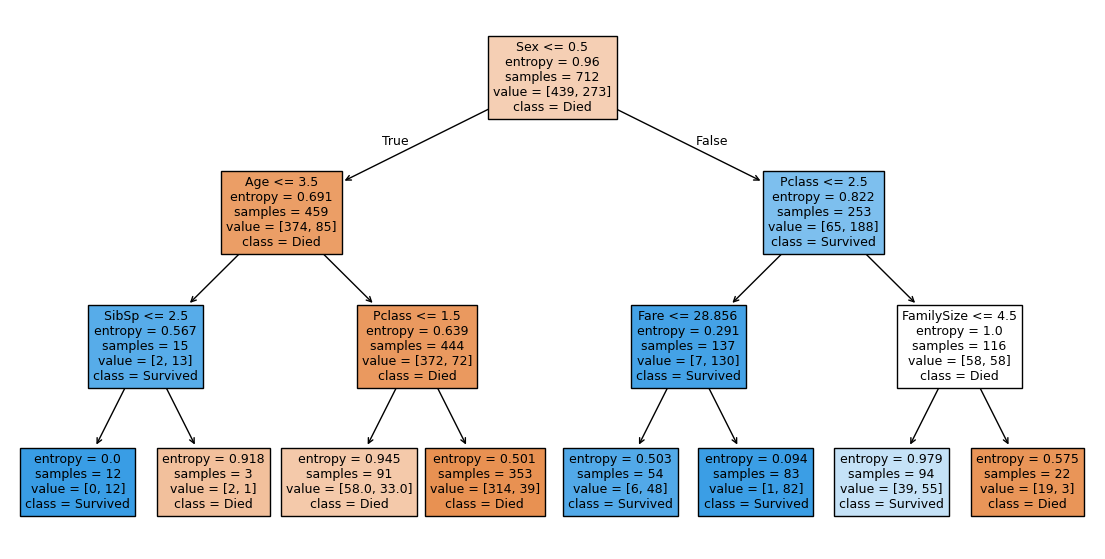

In [47]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

for crit in ["gini", "entropy"]:
    for depth in [2, 3, 5]:
        m = DecisionTreeClassifier(criterion=crit, max_depth=depth, random_state=42).fit(X_train, y_train)
        print(f"{crit:8s} depth={depth}  train={m.score(X_train, y_train):.3f}  test={m.score(X_test, y_test):.3f}")

dt = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42).fit(X_train, y_train)
plt.figure(figsize=(14, 7))
plot_tree(dt, feature_names=X.columns, class_names=["Died", "Survived"], filled=True)
plt.show()

**Random Forest from scratch:** bootstrap rows + random feature subsets + majority vote.

In [48]:
class SimpleRandomForest:
    def __init__(self, n_trees=10, max_depth=4, random_state=42):
        self.n_trees, self.max_depth, self.random_state = n_trees, max_depth, random_state
        self.trees = []

    def fit(self, X_, y_):
        rng = np.random.default_rng(self.random_state)
        self.trees = []
        for _ in range(self.n_trees):
            idx = rng.choice(len(X_), size=len(X_), replace=True)    # bootstrap sample
            tree_ = DecisionTreeClassifier(max_depth=self.max_depth, max_features="sqrt",
                                           random_state=int(rng.integers(0, 1_000_000)))
            tree_.fit(X_.iloc[idx], y_.iloc[idx])
            self.trees.append(tree_)

    def predict(self, X_):
        preds = np.array([t_.predict(X_) for t_ in self.trees])
        return np.array([Counter(preds[:, i]).most_common(1)[0][0]
                         for i in range(X_.shape[0])])               # majority vote

srf = SimpleRandomForest(n_trees=25); srf.fit(X_train, y_train)
print("Simple RF accuracy:", accuracy_score(y_test, srf.predict(X_test)))

Simple RF accuracy: 0.7877094972067039


**Random Forest (sklearn):** many decorrelated trees vote, lowers variance. Tune `n_estimators`, `max_depth`.

n_estimators 50 test acc 0.804
n_estimators 100 test acc 0.804
n_estimators 200 test acc 0.793
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



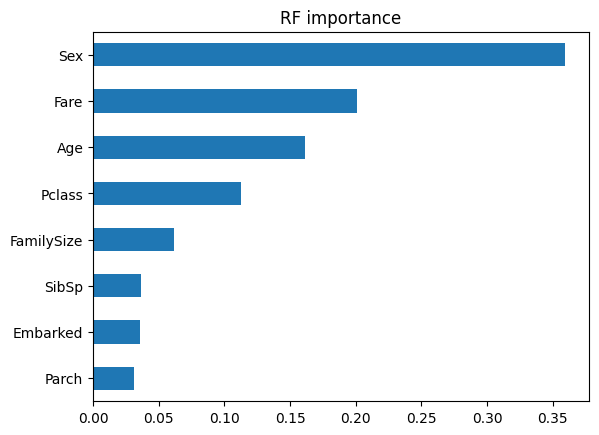

In [49]:
from sklearn.ensemble import RandomForestClassifier

for n in [50, 100, 200]:
    r_ = RandomForestClassifier(n_estimators=n, max_depth=8, random_state=42).fit(X_train, y_train)
    print("n_estimators", n, "test acc", round(r_.score(X_test, y_test), 3))

rf = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_split=4, random_state=42)
rf.fit(X_train, y_train)
print(classification_report(y_test, rf.predict(X_test)))
pd.Series(rf.feature_importances_, index=X.columns).sort_values().plot(kind="barh", title="RF importance")
plt.show()

**Boosting idea:** each weak learner fits the residuals of the current prediction.

In [50]:
from sklearn.tree import DecisionTreeRegressor

X_demo = np.array([[1], [2], [3], [4], [5], [6]])
y_demo = np.array([2, 4, 5, 8, 10, 12])
prediction = np.full(len(y_demo), y_demo.mean())           # start with the mean
for stage in range(3):
    residual = y_demo - prediction                          # current errors
    learner = DecisionTreeRegressor(max_depth=1, random_state=stage).fit(X_demo, residual)
    prediction = prediction + 0.3 * learner.predict(X_demo)   # 0.3 = learning rate
    print("Stage", stage + 1, np.round(prediction, 2))

Stage 1 [5.88 5.88 5.88 7.78 7.78 7.78]
Stage 2 [5.4  5.4  5.4  7.3  8.75 8.75]
Stage 3 [4.88 4.88 4.88 7.82 9.27 9.27]


**Gradient Boosting (sklearn):** sequential trees. Lower `learning_rate` needs more `n_estimators`.

In [51]:
from sklearn.ensemble import GradientBoostingClassifier

for lr_ in [0.01, 0.05, 0.1]:
    for n in [50, 100, 200]:
        g = GradientBoostingClassifier(n_estimators=n, learning_rate=lr_, max_depth=3, random_state=42).fit(X_train, y_train)
        print(f"lr={lr_:<5} n={n:<4} test acc={g.score(X_test, y_test):.3f}")

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42).fit(X_train, y_train)

lr=0.01  n=50   test acc=0.777
lr=0.01  n=100  test acc=0.793
lr=0.01  n=200  test acc=0.804
lr=0.05  n=50   test acc=0.799
lr=0.05  n=100  test acc=0.804
lr=0.05  n=200  test acc=0.804
lr=0.1   n=50   test acc=0.810
lr=0.1   n=100  test acc=0.804
lr=0.1   n=200  test acc=0.810


**XGBoost:** regularized, optimized boosting. Tune `max_depth` and `learning_rate`.

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



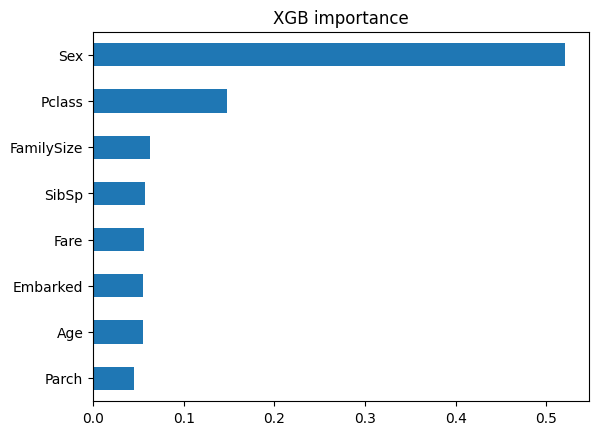

In [52]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                    subsample=0.8,            # row sampling per tree
                    colsample_bytree=0.8,     # feature sampling per tree
                    eval_metric="logloss", random_state=42).fit(X_train, y_train)
print(classification_report(y_test, xgb.predict(X_test)))
pd.Series(xgb.feature_importances_, index=X.columns).sort_values().plot(kind="barh", title="XGB importance")
plt.show()

**LightGBM:** fast, leaf-wise growth. Control `num_leaves` / `max_depth` to avoid overfitting on small data.

In [53]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31, max_depth=-1,
                      subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1).fit(X_train, y_train)
print(classification_report(y_test, lgbm.predict(X_test)))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83       110
           1       0.73      0.70      0.71        69

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



**Compare all 5 models:** accuracy, precision, recall, F1, confusion matrix.

In [54]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

all_models = {"DecisionTree": dt, "RandomForest": rf, "GradBoost": gb, "XGBoost": xgb, "LightGBM": lgbm}
rows = []
for name, m in all_models.items():
    p = m.predict(X_test)
    rows.append([name,
                 accuracy_score (y_test, p),
                 precision_score(y_test, p),
                 recall_score   (y_test, p),
                 f1_score       (y_test, p)
              ])

    print(name, "\n", confusion_matrix(y_test, p))
pd.DataFrame(rows, columns=["Model", "Acc", "Prec", "Rec", "F1"]).round(3)

DecisionTree 
 [[99 11]
 [24 45]]
RandomForest 
 [[97 13]
 [23 46]]
GradBoost 
 [[102   8]
 [ 27  42]]
XGBoost 
 [[97 13]
 [23 46]]
LightGBM 
 [[92 18]
 [21 48]]


,Model,Acc,Prec,Rec,F1
0,DecisionTree,0.804,0.804,0.652,0.720
1,RandomForest,0.799,0.780,0.667,0.719
2,GradBoost,0.804,0.840,0.609,0.706
3,XGBoost,0.799,0.780,0.667,0.719
4,LightGBM,0.782,0.727,0.696,0.711


# LAB 5: Linear Regression
Titanic has a binary target, so this lab predicts the **continuous** column `Fare` from the other features.

In [55]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score

reg_feats = ["Pclass", "Sex", "Age", "SibSp", "Parch"]
Xr, yr = tr[reg_feats], tr["Fare"]
xr_train, xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)

**Simple LR:** one feature (`Pclass` -> `Fare`).

R2 %: 30.988588438531096
Slope (Coefficient): [-34.46177053]
Intercept: 112.88413750882464


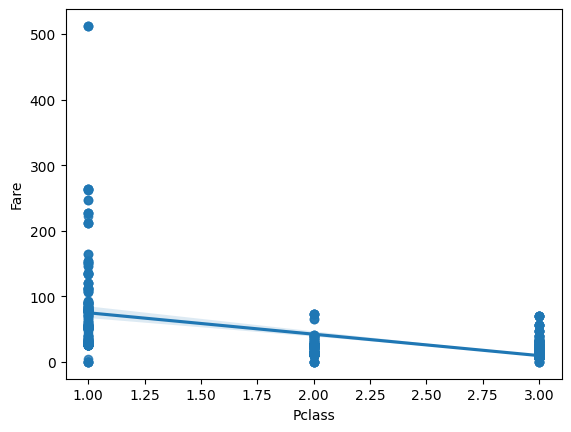

In [56]:
LR = LinearRegression()
ModelLR = LR.fit(xr_train[["Pclass"]], yr_train)
PredictionLR = ModelLR.predict(xr_test[["Pclass"]])
print("R2 %:", r2_score(yr_test, PredictionLR) * 100)

print("Slope (Coefficient):", ModelLR.coef_)     # change in Fare per unit Pclass
print("Intercept:", ModelLR.intercept_)          # Fare when Pclass = 0
sns.regplot(x="Pclass", y="Fare", data=tr)       # scatter + fitted line
plt.show()

**Multiple LR:** same code, more feature columns.

In [57]:
ModelLR2 = LinearRegression().fit(xr_train, yr_train)
pred2 = ModelLR2.predict(xr_test)
print("R2:", r2_score(yr_test, pred2))
print(dict(zip(reg_feats, ModelLR2.coef_.round(2))), "| intercept", round(ModelLR2.intercept_, 2))

R2: 0.39534273434575706
{'Pclass': np.float64(-35.58), 'Sex': np.float64(4.81), 'Age': np.float64(-0.13), 'SibSp': np.float64(5.27), 'Parch': np.float64(10.47)} | intercept 110.86


**Assumption checks:** funnel-shaped residuals = heteroscedasticity; check normality and multicollinearity.

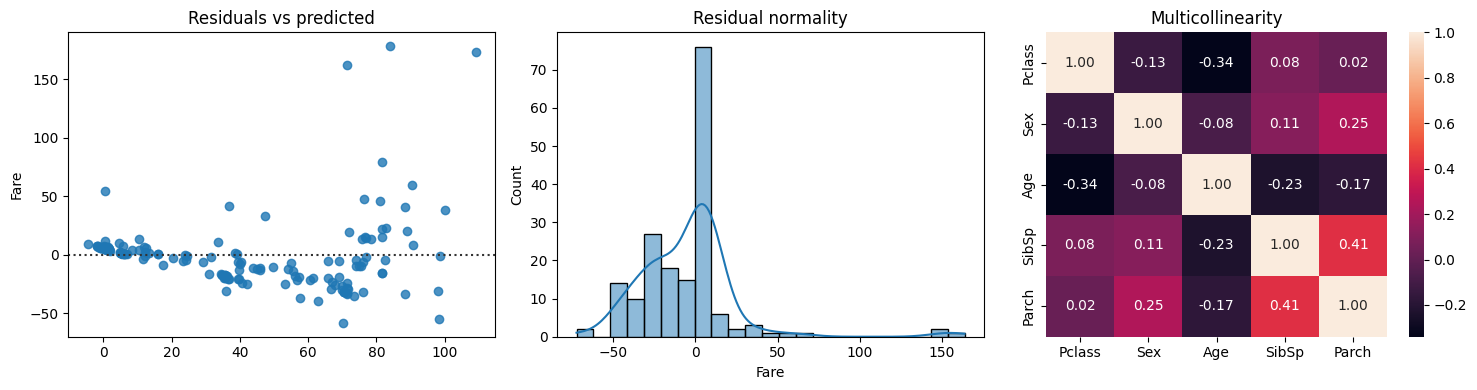

In [58]:
residuals = yr_test - pred2
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.residplot(x=pred2, y=residuals, ax=ax[0]); ax[0].set_title("Residuals vs predicted")
sns.histplot(residuals, kde=True, ax=ax[1]); ax[1].set_title("Residual normality")
sns.heatmap(Xr.corr(), annot=True, fmt=".2f", ax=ax[2]); ax[2].set_title("Multicollinearity")
plt.tight_layout(); plt.show()

**Polynomial regression:** curve fit by adding powers of x. Too high a degree overfits; choose by CV.

In [59]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

for deg in [1, 2, 3, 5]:
    pm = make_pipeline(PolynomialFeatures(deg), LinearRegression()).fit(xr_train[["Age"]], yr_train)
    print(f"degree {deg}: train R2 {pm.score(xr_train[['Age']], yr_train):.3f} | test R2 {pm.score(xr_test[['Age']], yr_test):.3f}")

degree 1: train R2 0.008 | test R2 0.015
degree 2: train R2 0.010 | test R2 0.019
degree 3: train R2 0.015 | test R2 0.024
degree 5: train R2 0.017 | test R2 0.028


**Ridge (L2) and Lasso (L1):** regularized LR.

In [60]:
print("Ridge R2:", Ridge(alpha=1.0).fit(xr_train, yr_train).score(xr_test, yr_test))
lasso = Lasso(alpha=0.1).fit(xr_train, yr_train)
print("Lasso R2:", lasso.score(xr_test, yr_test), "| coefs:", lasso.coef_.round(2))

Ridge R2: 0.39598268126214664
Lasso R2: 0.39644767692923955 | coefs: [-35.45   4.43  -0.13   5.23  10.39]


**Actual vs predicted plot** (train and test results).

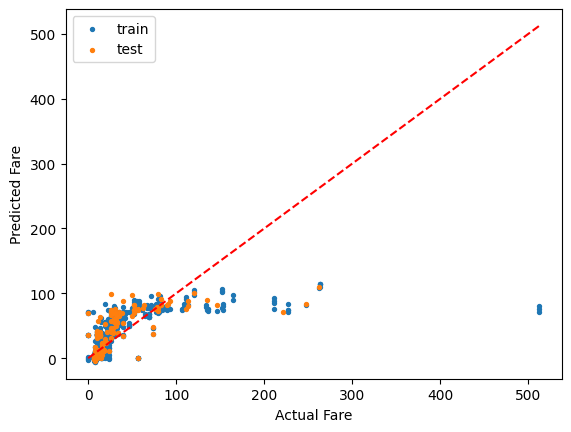

In [61]:
plt.scatter(yr_train, ModelLR2.predict(xr_train), s=8, label="train")
plt.scatter(yr_test, pred2, s=8, label="test")
plt.plot([yr.min(), yr.max()], [yr.min(), yr.max()], "r--")
plt.xlabel("Actual Fare"); plt.ylabel("Predicted Fare"); plt.legend(); plt.show()

# LAB 6: Evaluation, Cross-Validation, Tuning

**Train vs test gap:** large gap = overfitting.

In [62]:
from sklearn.tree import DecisionTreeClassifier
deep = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)    # unlimited depth
print("Train:", round(deep.score(X_train, y_train), 3), "| Test:", round(deep.score(X_test, y_test), 3))

Train: 0.982 | Test: 0.799


**Classification metrics from the confusion matrix** (Random Forest, hyperparameters set before training).

Accuracy    0.81
Precision   0.857 (of predicted survivors, how many right)
Recall      0.609 (of actual survivors, how many found)
Specificity 0.936 (of actual deaths, how many rejected)
F1          0.712
ROC-AUC     0.847
PR-AUC      0.83


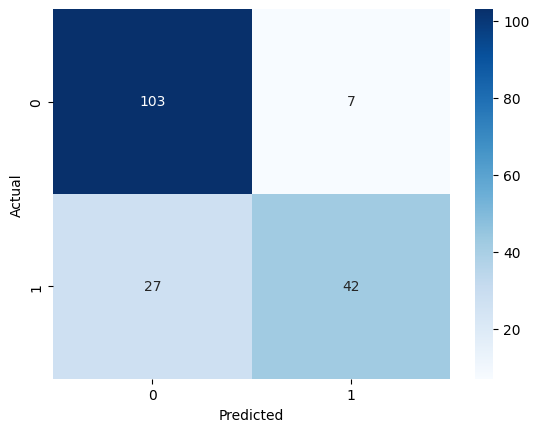

In [63]:
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score)

rf6 = RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_split=4, random_state=42).fit(X_train, y_train)
y_pred = rf6.predict(X_test)
y_prob = rf6.predict_proba(X_test)[:, 1]          # probabilities, not labels

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()   # rows=actual, cols=predicted
print("Accuracy   ", round(accuracy_score(y_test, y_pred), 3))
print("Precision  ", round(precision_score(y_test, y_pred), 3), "(of predicted survivors, how many right)")
print("Recall     ", round(recall_score(y_test, y_pred), 3), "(of actual survivors, how many found)")
print("Specificity", round(tn / (tn + fp), 3), "(of actual deaths, how many rejected)")
print("F1         ", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC    ", round(roc_auc_score(y_test, y_prob), 3))
print("PR-AUC     ", round(average_precision_score(y_test, y_prob), 3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

**Regression metrics** (on the Lab 5 Fare model).

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(yr_test, pred2)          # avg |error|
mse  = mean_squared_error(yr_test, pred2)           # penalizes big errors
rmse = np.sqrt(mse)                                 # same units as target
r2   = r2_score(yr_test, pred2)                     # variance explained
print(f"MAE {mae:.2f} | MSE {mse:.2f} | RMSE {rmse:.2f} | R2 {r2:.3f}")

MAE 19.68 | MSE 935.66 | RMSE 30.59 | R2 0.395


**K-Fold, Stratified, Repeated K-Fold, LOOCV, TimeSeriesSplit** on the training data.

In [65]:
from sklearn.model_selection import (KFold, StratifiedKFold, RepeatedKFold, LeaveOneOut,
                                     TimeSeriesSplit, cross_val_score)

def report(name, scores):
    print(f"{name:16s} n={len(scores):<4} mean={scores.mean():.3f} std={scores.std():.3f}")

report("KFold", cross_val_score(rf6, X_train, y_train, cv=KFold(5, shuffle=True, random_state=42)))
report("StratifiedKFold", cross_val_score(rf6, X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring="f1"))
report("RepeatedKFold", cross_val_score(rf6, X_train, y_train, cv=RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)))
report("TimeSeriesSplit", cross_val_score(rf6, X_train, y_train, cv=TimeSeriesSplit(n_splits=5)))

# LOOCV only on a small subset (it fits one model per row)
from sklearn.linear_model import LogisticRegression
Xs, ys = X_train.head(100), y_train.head(100)
report("LOOCV (100 rows)", cross_val_score(LogisticRegression(max_iter=1000), Xs, ys, cv=LeaveOneOut()))
print("Test accuracy for comparison:", round(rf6.score(X_test, y_test), 3))

KFold            n=5    mean=0.820 std=0.024
StratifiedKFold  n=5    mean=0.740 std=0.032
RepeatedKFold    n=15   mean=0.822 std=0.024
TimeSeriesSplit  n=5    mean=0.827 std=0.031
LOOCV (100 rows) n=100  mean=0.770 std=0.421
Test accuracy for comparison: 0.81


**Pipeline + Grid Search + Random Search:** scaling stays inside each fold (no data leakage). Parameters are named `step__param`.

In [66]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

pipe = Pipeline([("scaler", StandardScaler()),
                 ("model", LogisticRegression(max_iter=1000))])
print("Pipeline CV:", cross_val_score(pipe, X_train, y_train, cv=5).mean().round(3))

grid = GridSearchCV(pipe, {"model__C": [0.01, 0.1, 1, 10]}, cv=5, scoring="f1").fit(X_train, y_train)
print("Grid best:", grid.best_params_, round(grid.best_score_, 3))

rs = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                        {"max_depth": [3, 5, 8, None], "n_estimators": [50, 100, 200],
                         "min_samples_split": [2, 5, 10]},
                        n_iter=5, cv=5, scoring="f1", random_state=42).fit(X_train, y_train)
print("Random best:", rs.best_params_, round(rs.best_score_, 3))
best_model = rs.best_estimator_

Pipeline CV: 0.796
Grid best: {'model__C': 1} 0.725
Random best: {'n_estimators': 50, 'min_samples_split': 5, 'max_depth': None} 0.751


**Regularization:** smaller `C` = stronger regularization.

In [67]:
for C in [0.01, 1, 100]:
    m = LogisticRegression(C=C, penalty="l2", max_iter=2000).fit(StandardScaler().fit_transform(X_train), y_train)
    print("C =", C, "| max |coef| =", np.abs(m.coef_).max().round(3))

C = 0.01 | max |coef| = 0.669
C = 1 | max |coef| = 1.269
C = 100 | max |coef| = 1.287


**Imbalanced data:** baseline shows why accuracy misleads; then `class_weight='balanced'`. (Titanic is only mildly imbalanced, ~38% survived.)

In [68]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
p = dummy.predict(X_test)
print("Dummy accuracy:", round(accuracy_score(y_test, p), 3), "| recall:", recall_score(y_test, p, zero_division=0))

for cw in [None, "balanced"]:
    m = RandomForestClassifier(class_weight=cw, random_state=42).fit(X_train, y_train)
    p = m.predict(X_test)
    print(f"class_weight={str(cw):9s} acc={accuracy_score(y_test,p):.3f} prec={precision_score(y_test,p):.3f} "
          f"rec={recall_score(y_test,p):.3f} f1={f1_score(y_test,p):.3f}")

Dummy accuracy: 0.615 | recall: 0.0
class_weight=None      acc=0.816 prec=0.773 rec=0.739 f1=0.756
class_weight=balanced  acc=0.816 prec=0.773 rec=0.739 f1=0.756


**Learning curve:** diagnose over- or underfitting.

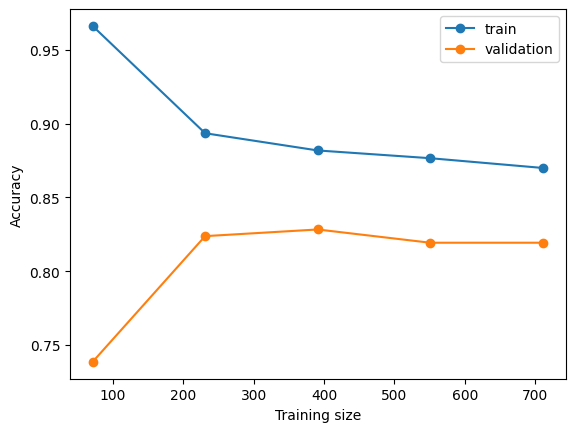

In [69]:
from sklearn.model_selection import learning_curve

sizes, train_sc, val_sc = learning_curve(rf6, X, y, cv=5)
plt.plot(sizes, train_sc.mean(axis=1), "o-", label="train")
plt.plot(sizes, val_sc.mean(axis=1), "o-", label="validation")
plt.xlabel("Training size"); plt.ylabel("Accuracy"); plt.legend(); plt.show()

# Kaggle Submission (`submission.csv`)

In [70]:
final_model = best_model                      # or xgb / gb / lgbm
final_model.fit(X, y)                         # refit on ALL labeled data

if test is not None:
    te = prep(test)
    submission = pd.DataFrame({"PassengerId": test["PassengerId"],
                               "Survived": final_model.predict(te[features])})
    submission.to_csv("submission.csv", index=False)
    print(submission.shape)                   # (418, 2) for the real competition
    print(submission.head())
else:
    print("No test.csv loaded (seaborn fallback) - download it from the Kaggle Titanic page to build submission.csv")

(418, 2)
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         1


# Cheat Sheet

**Workflow:** load -> `info/describe/isnull` -> EDA plots -> clean + encode -> stratified split -> baseline -> models -> CV -> tune -> test metrics -> `submission.csv`

**Formulas**

$$H(Y)=-\sum_v p(v)\log_2 p(v)\qquad I(Y;X)=H(Y)-H(Y|X)\qquad Gini=1-\sum p_i^2$$

$$Acc=\frac{TP+TN}{TP+TN+FP+FN}\quad P=\frac{TP}{TP+FP}\quad R=\frac{TP}{TP+FN}\quad Spec=\frac{TN}{TN+FP}\quad F1=\frac{2PR}{P+R}$$

$$MAE=\frac1n\sum|y-\hat y|\quad MSE=\frac1n\sum(y-\hat y)^2\quad RMSE=\sqrt{MSE}\quad R^2=1-\frac{\sum(y-\hat y)^2}{\sum(y-\bar y)^2}$$

$$y=\beta_0+\beta_1x_1+\dots+\beta_px_p+\varepsilon\qquad \varepsilon_i=y_{pred}-y_i$$

| Situation | Metric |
|---|---|
| False positives costly (spam) | Precision |
| False negatives costly (disease) | Recall |
| Imbalanced / rare class (fraud) | F1, PR-AUC |
| Ranking / separation | ROC-AUC (1 = perfect, 0.5 = random) |
| Regression with outliers | MAE (RMSE punishes big errors) |
| Variance explained | R2 |

| Data | CV splitter |
|---|---|
| General | `KFold` |
| Classification / imbalanced | `StratifiedKFold` |
| Stable estimate | `RepeatedKFold` |
| Tiny dataset | `LeaveOneOut` |
| Time-ordered | `TimeSeriesSplit` |

| Model | Key idea | Risk |
|---|---|---|
| Decision Tree | Recursive splits | Overfits |
| Random Forest | Bagging + voting, lowers variance | Large, opaque |
| Gradient Boosting | Sequential residual fitting, lowers bias | Sensitive to tuning |
| XGBoost | Regularized boosting | Many hyperparameters |
| LightGBM | Leaf-wise, fast | Overfits small data (limit `num_leaves`) |

**Fit diagnosis:** train + test both low = underfit (more complexity/features, boosting). Train high, test low = overfit (lower depth, regularize, more data, bagging).

**LR assumptions:** linearity, independence, homoscedasticity, normal residuals, no multicollinearity, no autocorrelation, additivity.

**Pitfalls:** data leakage (scale inside a `Pipeline`), touching the test set early, accuracy on imbalanced data, missing `random_state`, unencoded categoricals/NaNs, ID columns as features.